In [2]:
import requests
import pandas as pd
import os
import time
from getpass import getpass

# ============================================================
# 1. LOAD KOBO API TOKEN SECURELY
# ============================================================

# Try to load variables from a local .env file
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass


API_TOKEN = None


# Try Google Colab Secrets
try:
    from google.colab import userdata

    try:
        API_TOKEN = userdata.get("KOBO_API_TOKEN")
    except userdata.SecretNotFoundError:
        pass

except ImportError:
    pass


# Try standard environment variable
if not API_TOKEN:
    API_TOKEN = os.environ.get("KOBO_API_TOKEN")


# Secure interactive fallback
if not API_TOKEN:
    print(
        "KOBO_API_TOKEN was not found in Colab Secrets, "
        ".env file, or environment variables."
    )

    API_TOKEN = getpass("Please enter your KoboToolbox API Token: ")

    if not API_TOKEN:
        raise ValueError("API Token cannot be empty. Script stopped.")


# ============================================================
# 2. KOBO API CONFIGURATION
# ============================================================

ASSET_UID = "aPRutS6LChsVTzgdynWjYo"
BASE_URL = "https://eu.kobotoolbox.org"

headers = {
    "Authorization": f"Token {API_TOKEN}"
}

url = f"{BASE_URL}/api/v2/assets/{ASSET_UID}/data/"


# ============================================================
# 3. FETCH ALL SUBMISSIONS
# ============================================================

all_results = []
page = 0

while url:

    page += 1

    for attempt in range(3):

        try:
            response = requests.get(
                url,
                headers=headers,
                timeout=30
            )

            response.raise_for_status()
            break

        except requests.RequestException as e:

            if attempt == 2:
                raise

            print(f"Retry {attempt + 1}/3 after error: {e}")
            time.sleep(2 ** attempt)

    payload = response.json()

    results = payload.get("results", [])

    if not isinstance(results, list):
        raise ValueError(
            f"Unexpected API payload keys: {list(payload.keys())}"
        )

    all_results.extend(results)

    print(
        f"Page {page}: +{len(results)} "
        f"(total {len(all_results)})"
    )

    url = payload.get("next")


# ============================================================
# 4. CONVERT TO DATAFRAME
# ============================================================

df_raw = pd.DataFrame(all_results)

print(
    f"\nPulled {len(df_raw):,} submissions "
    f"with {df_raw.shape[1]} columns."
)

Retry 1/3 after error: HTTPSConnectionPool(host='eu.kobotoolbox.org', port=443): Max retries exceeded with url: /api/v2/assets/aPRutS6LChsVTzgdynWjYo/data/ (Caused by NameResolutionError("HTTPSConnection(host='eu.kobotoolbox.org', port=443): Failed to resolve 'eu.kobotoolbox.org' ([Errno 11001] getaddrinfo failed)"))
Retry 2/3 after error: HTTPSConnectionPool(host='eu.kobotoolbox.org', port=443): Max retries exceeded with url: /api/v2/assets/aPRutS6LChsVTzgdynWjYo/data/ (Caused by NameResolutionError("HTTPSConnection(host='eu.kobotoolbox.org', port=443): Failed to resolve 'eu.kobotoolbox.org' ([Errno 11001] getaddrinfo failed)"))


ConnectionError: HTTPSConnectionPool(host='eu.kobotoolbox.org', port=443): Max retries exceeded with url: /api/v2/assets/aPRutS6LChsVTzgdynWjYo/data/ (Caused by NameResolutionError("HTTPSConnection(host='eu.kobotoolbox.org', port=443): Failed to resolve 'eu.kobotoolbox.org' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
# Immutable copy — never touch again
df_raw_backup = df_raw.copy()

# Working copy for cleaning
df_clean = df_raw.copy()

print(f"Working DataFrame: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

Working DataFrame: 1,593 rows × 64 columns


In [ ]:
from IPython.display import display

display(df_clean.info())
display(df_clean.head(3))
display(df_clean.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 64 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   _id                                  1593 non-null   int64 
 1   start                                1593 non-null   str   
 2   end                                  1593 non-null   str   
 3   Date_and_Time                        1593 non-null   str   
 4   Month                                1593 non-null   str   
 5   division                             1593 non-null   str   
 6   Premises                             1593 non-null   str   
 7   Food_Premises_Class                  1251 non-null   str   
 8   Name_of_Organization                 1586 non-null   str   
 9   Location                             1593 non-null   str   
 10  Take_a_picture_of_the_approach       1593 non-null   str   
 11  Email_address                        104 non-null    s

None

,_id,start,end,Date_and_Time,Month,division,Premises,Food_Premises_Class,Name_of_Organization,Location,...,Inspector_Code,If_Yes_Name,Contact_Number,Any_other_Contact_001,If_No_List_all_the_missing_document,Nuisance_7_Identified,Take_evidence_006,If_Others_please_specify,If_Yes_Name_001,Contact_Number_001
0,595643066,2024-09-17T11:46:26.640+01:00,2024-09-20T13:09:30.724+01:00,2024-09-17T11:53:00+01:00,September,Lagos_Island_Division_1,Regulated_Food_Premises,Restaurant_&_Cafes,Mega plaza,6.433303 3.420723 29.900001525878906 34.834999...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,595648231,2024-09-17T13:03:53.690+01:00,2024-09-20T13:11:37.961+01:00,2024-09-17T13:04:00+01:00,September,Lagos_Island_Division_1,Regulated_Food_Premises,Hotels,Sun Heaven Hotel and Suites,6.43361 3.417223 26.200000762939453 13.0260000...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,595668794,2024-09-17T14:16:05.743+01:00,2024-09-20T13:13:25.218+01:00,2024-09-17T14:16:00+01:00,September,Lagos_Island_Division_1,Regulated_Food_Premises,Restaurant_&_Cafes,Crust and Cream Restaurant,6.43219 3.415706 26.200000762939453 16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,_id,start,end,Date_and_Time,Month,division,Premises,Food_Premises_Class,Name_of_Organization,Location,...,Inspector_Code,If_Yes_Name,Contact_Number,Any_other_Contact_001,If_No_List_all_the_missing_document,Nuisance_7_Identified,Take_evidence_006,If_Others_please_specify,If_Yes_Name_001,Contact_Number_001
count,1.593000e+03,1593,1593,1593,1593,1593,1593,1251,1586,1593,...,1425,68,61,45,244,66,59,39,2,2
unique,NaN,1593,1593,1589,13,5,4,14,1393,1589,...,91,68,61,2,219,66,59,19,2,2
top,NaN,2024-09-17T11:46:26.640+01:00,2024-09-20T13:09:30.724+01:00,2024-10-23T12:58:00.000+01:00,October,Lagos_Island_Division_1,Regulated_Food_Premises,Restaurant_&_Cafes,The place,6.444204 3.454711 5.918736934661865 59.4394279...,...,EHO,Mr Yaseen,08060363165,no,Valid medical certificate of fitness for all t...,"Presence of feacal matter, emitting obnoxious ...",1726756932968.jpg,Bar,Mr Emmanuel,08077892470
freq,NaN,1,1,2,200,864,1251,427,9,2,...,596,1,1,43,5,1,1,10,1,1
mean,7.130060e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6.954878e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,5.956431e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,6.521983e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7.110149e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.735588e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_clean.isnull().sum()

_id                            0
start                          0
end                            0
Date_and_Time                  0
Month                          0
                            ... 
Nuisance_7_Identified       1510
Take_evidence_006           1517
If_Others_please_specify    1537
If_Yes_Name_001             1574
Contact_Number_001          1574
Length: 64, dtype: int64

In [ ]:
# =============================
#       DATA CLEANING
# =============================

df_clean.columns = (
    df_clean.columns
    .str.strip()
)

# Clean text fields: remove leading/trailing spaces and standardize capitalization
text_columns = [
    "Inspection_type",
    "division",
    "Premises",
    "Food_Premises_Class",
    "Non_Food_Premises_Class",
    "Do_you_sight_any_nuisance",
    "Was_Abatement_Notice_served"
]

for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype("string")
            .str.strip()
        )

In [ ]:
# Standardize Inspection_type
df_clean["Inspection_type"] = (
    df_clean["Inspection_type"]
    .str.title()
)

In [ ]:
# Fix _1 suffixes
df_clean["division"] = (
    df_clean["division"]
    .astype("string")
    .str.strip()
    .str.replace(r"_1$", "", regex=True)
)

In [ ]:
# Convert date
df_clean["Date_and_Time"] = pd.to_datetime(
    df_clean["Date_and_Time"],
    errors="coerce"
)

In [ ]:
# Check fixes
df_clean["Date_and_Time"].isna().sum()

np.int64(1267)

In [ ]:
# Check missing data
missing = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

In [ ]:
# Standardize categorical values

categorical_colums = [
    "Inspection_type",
    "division",
]

for col in categorical_colums:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
    )

In [ ]:
# Check missing values
df_clean.isnull().sum().sort_values(ascending=False)

Contact_Number_001                1574
If_Yes_Name_001                   1574
If_Others_please_specify          1537
Any_other_Contact_001             1531
meta/deprecatedID                 1530
                                  ... 
meta/instanceID                      0
Do_you_sight_any_nuisance            0
Inspector_Remarks                    0
Take_a_picture_of_the_approach       0
Select_Documents_sighted             0
Length: 64, dtype: int64

In [ ]:
# Find columns with problems

list_columns = [col for col in df.columns if df[col].apply(lambda x: isinstance(x, list)).any()]
print("Columns containing lists:", list_columns)


Columns containing lists: ['_attachments', '_geolocation']


In [ ]:
# Convert columns to plain text if they contain lists
for col in list_columns:
    df[col] = df[col].apply(lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x)

In [ ]:
nested_columns = df.columns[
    df.map(lambda value: isinstance(value, (list, dict))).any()
]
print(nested_columns.tolist())

['_validation_status']


In [ ]:
import json

df_sql = df.map(
    lambda value: json.dumps(value) if isinstance(value, (list, dict)) else value
)
conn = sqlite3.connect("kobo_data.db")
df_sql.to_sql("submissions", conn, if_exists="replace", index=False)

1576

In [ ]:
# Push to sqlite

conn = sqlite3.connect("kobo_data.db")
df_sql.to_sql("submissions", conn, if_exists="replace", index=False)

print("Loaded into SQlite. Tables:")
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn).values.flatten())

Loaded into SQlite. Tables:
['submissions']


In [ ]:
pd.read_sql("PRAGMA table_info(submissions);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,_id,INTEGER,0,None,0
1,1,start,TEXT,0,None,0
2,2,end,TEXT,0,None,0
3,3,Date_and_Time,TEXT,0,None,0
4,4,Month,TEXT,0,None,0
...,...,...,...,...,...,...
59,59,Nuisance_7_Identified,TEXT,0,None,0
60,60,Take_evidence_006,TEXT,0,None,0
61,61,If_Others_please_specify,TEXT,0,None,0
62,62,If_Yes_Name_001,TEXT,0,None,0


In [ ]:
#Inspections per Division per Month

query = """
SELECT division, Month, COUNT(*) AS inspection_count
FROM submissions
GROUP BY division, Month
ORDER BY division, Month;
"""

pd.read_sql(query, conn)

,division,Month,inspection_count
0,1,january,1
1,Badagry_Division_1,April,2
2,Badagry_Division_1,August,11
3,Badagry_Division_1,December,4
4,Badagry_Division_1,February,22
5,Badagry_Division_1,July,8
6,Badagry_Division_1,June,6
7,Badagry_Division_1,March,19
8,Badagry_Division_1,May,6
9,Badagry_Division_1,November,6


In [ ]:
pd.read_sql("SELECT division, COUNT(*) FROM submissions WHERE division = '1' GROUP BY division;", conn)
pd.read_sql("SELECT DISTINCT Do_you_sight_any_nuisance FROM submissions;", conn)
pd.read_sql("SELECT DISTINCT Nuisance_1_Identified FROM submissions LIMIT 20;", conn)

,Nuisance_1_identified
0,NaN
1,Insanitary heaped and deposition of refuse
2,Failure to provide toilet facilities
3,Insanitary overhanging of clothes in and aroun...
4,Defective ceiling ( pop)
5,Exposed refuse bin in the kitchen
6,Indiscriminate dumping of refuse on bare floor...
7,Evidence of flies infestation to the kitchen a...
8,Unscreened kitchen extractor leading to direct...
9,Insanitary dumping of refuse on the bare floor...


In [ ]:
pd.read_sql("SELECT DISTINCT Do_you_sight_any_nuisance FROM submissions;", conn)

,Do_you_sight_any_nuisance
0,No_1
1,Compliant
2,Non-Compliant


In [ ]:
pd.read_sql("SELECT Do_you_sight_any_nuisance, COUNT(*) FROM submissions GROUP BY Do_you_sight_any_nuisance;", conn)

,Do_you_sight_any_nuisance,COUNT(*)
0,Compliant,582
1,No_1,4
2,Non-Compliant,990


In [ ]:
# Overall Compliance Rate

query = """
SELECT
    Do_you_sight_any_nuisance AS compliance_status,
    COUNT(*) AS count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM submissions), 2) AS percentage
FROM submissions
GROUP BY Do_you_sight_any_nuisance;
"""

pd.read_sql(query, conn)

,compliance_status,count,percentage
0,Compliant,582,36.93
1,No_1,4,0.25
2,Non-Compliant,990,62.82


In [ ]:
# Compliance rate by division

query = """
SELECT
    division,
    SUM(CASE WHEN Do_you_sight_any_nuisance = 'Compliant' THEN 1 ELSE 0 END) AS compliant_count,
    SUM(CASE WHEN Do_you_sight_any_nuisance = 'Non-Compliant' THEN 1 ELSE 0 END) AS non_compliant_count,
    COUNT(*) AS total_inspections,
    ROUND(100.0 * SUM(CASE WHEN Do_you_sight_any_nuisance = 'Compliant' THEN 1 ELSE 0 END) / COUNT(*), 1) AS compliance_rate_pct
FROM submissions
GROUP BY division
ORDER BY compliance_rate_pct DESC;
"""

pd.read_sql(query, conn)

,division,compliant_count,non_compliant_count,total_inspections,compliance_rate_pct
0,Ikorodu-Epe_Division_1,288,86,374,77.0
1,Badagry_Division_1,48,91,139,34.5
2,Lagos_Island_Division_1,222,632,856,25.9
3,Ikeja_Division_1,24,181,206,11.7
4,1,0,0,1,0.0


In [ ]:
# Inspections per division per month
query = """
SELECT division, Month, COUNT(*) AS inspection_count
FROM submissions
GROUP BY division, Month
ORDER BY division, Month;
"""

pd.read_sql(query, conn)

,division,Month,inspection_count
0,1,january,1
1,Badagry_Division_1,April,2
2,Badagry_Division_1,August,11
3,Badagry_Division_1,December,4
4,Badagry_Division_1,February,22
5,Badagry_Division_1,July,8
6,Badagry_Division_1,June,6
7,Badagry_Division_1,March,19
8,Badagry_Division_1,May,6
9,Badagry_Division_1,November,6


In [ ]:
# Trend over time
query = """
SELECT Month, COUNT(*) AS inspection_count
FROM submissions
GROUP BY Month
ORDER BY Month;
"""

pd.read_sql(query, conn)

,Month,inspection_count
0,April,176
1,August,112
2,December,51
3,February,150
4,January,1
5,July,147
6,June,117
7,March,184
8,May,148
9,November,107


In [ ]:
# Nuisance type breakdown
query = """
SELECT nuisance_type, COUNT(*) AS occurrences
FROM(
    SELECT Nuisance_1_Identified AS nuisance_type FROM submissions WHERE Nuisance_1_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_2_Identified FROM submissions WHERE Nuisance_2_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_3_Identified FROM submissions WHERE Nuisance_3_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_4_Identified FROM submissions WHERE Nuisance_4_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_5_Identified FROM submissions WHERE Nuisance_5_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_6_Identified FROM submissions WHERE Nuisance_6_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_7_Identified FROM submissions WHERE Nuisance_7_Identified IS NOT NULL
) AS all_nuisances
GROUP BY nuisance_type
ORDER BY occurrences DESC;
"""

pd.read_sql(query, conn)

,nuisance_type,occurrences
0,Accumulation of miscellaneous articles,17
1,Accumulation of miscellaneous articles,13
2,Defective fat trap,11
3,Insanitary refuse bin,9
4,Evidence of excessive heat inside the kitchen ...,7
...,...,...
2621,1.Insanitary toilet pit latrine emitting offen...,1
2622,1.Insanitary production leading to exposing o...,1
2623,1. Indiscriminate/illegal dumping of waste (re...,1
2624,1. Failed to provide a toilet facility within ...,1


In [ ]:
# Make Date and Time proper

df['Date_and_Time'] = pd.to_datetime(df['Date_and_Time'], errors='coerce')

In [ ]:
df['Date_and_Time'].dtype

datetime64[us, UTC+01:00]

In [ ]:
# Montly inspection counts

monthly_inspections = (
    df.set_index('Date_and_Time')
    .resample('ME')
    .size()
)

In [ ]:
monthly_inspections

Date_and_Time
2024-09-30 00:00:00+01:00    16
2024-10-31 00:00:00+01:00    18
2024-11-30 00:00:00+01:00     0
2024-12-31 00:00:00+01:00     0
2025-01-31 00:00:00+01:00     0
2025-02-28 00:00:00+01:00    61
2025-03-31 00:00:00+01:00    52
2025-04-30 00:00:00+01:00    24
2025-05-31 00:00:00+01:00    21
2025-06-30 00:00:00+01:00    23
2025-07-31 00:00:00+01:00    26
2025-08-31 00:00:00+01:00     4
2025-09-30 00:00:00+01:00     5
2025-10-31 00:00:00+01:00    23
2025-11-30 00:00:00+01:00     7
2025-12-31 00:00:00+01:00     6
2026-01-31 00:00:00+01:00     0
2026-02-28 00:00:00+01:00     6
2026-03-31 00:00:00+01:00     1
2026-04-30 00:00:00+01:00     0
2026-05-31 00:00:00+01:00     0
2026-06-30 00:00:00+01:00     0
2026-07-31 00:00:00+01:00     0
2026-08-31 00:00:00+01:00     2
2026-09-30 00:00:00+01:00    11
2026-10-31 00:00:00+01:00     3
dtype: int64

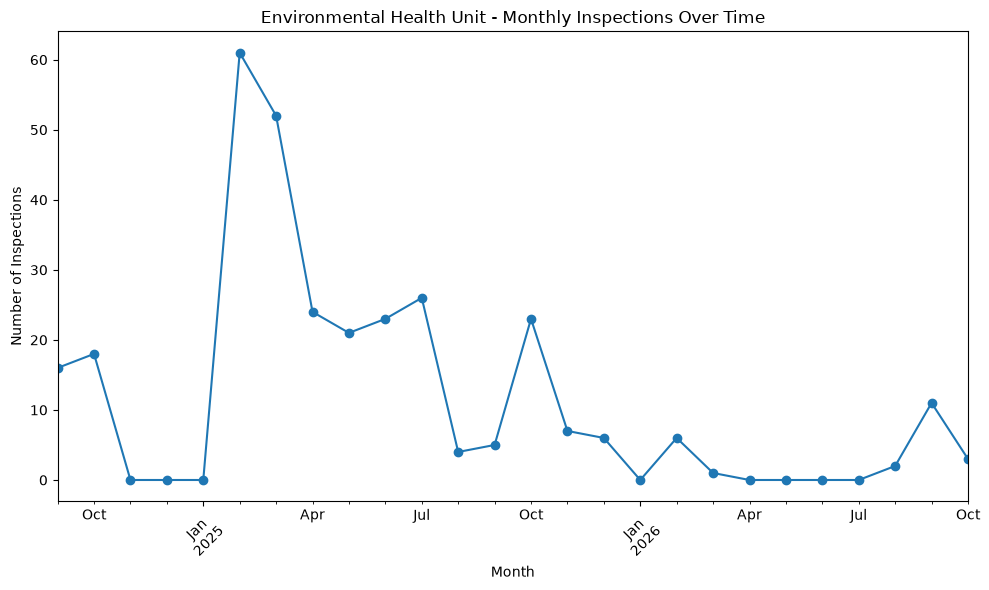

In [ ]:
# Visualization of Monthly Inspections in Line Chart
import matplotlib.pyplot as plt

monthly_inspections.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Environmental Health Unit - Monthly Inspections Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Monthly/Division Table

division_monthly = (
    df.groupby([
        pd.Grouper(key='Date_and_Time', freq='ME'),
        'division'
    ])
    .size()
    .reset_index(name='inspection_count')
)

division_monthly.head()

,Date_and_Time,division,inspection_count
0,2024-09-30 00:00:00+01:00,Badagry_Division_1,9
1,2024-09-30 00:00:00+01:00,Ikeja_Division_1,1
2,2024-09-30 00:00:00+01:00,Lagos_Island_Division_1,6
3,2024-10-31 00:00:00+01:00,Badagry_Division_1,18
4,2025-02-28 00:00:00+01:00,Badagry_Division_1,12


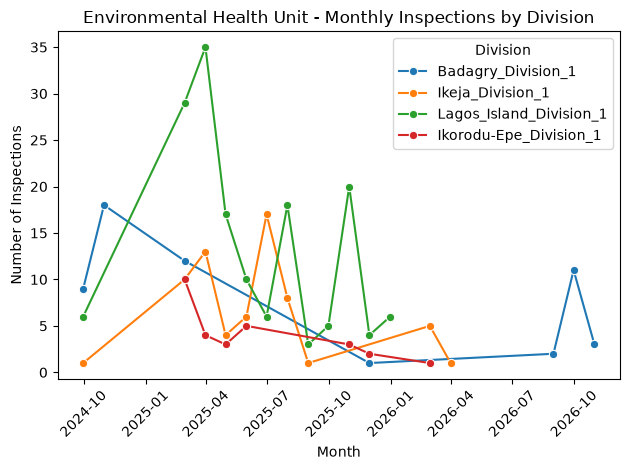

In [ ]:
# Visualization of Monthly Inspections by Division
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=division_monthly,
    x='Date_and_Time',
    y='inspection_count',
    hue='division',
    marker='o',
)

plt.title('Environmental Health Unit - Monthly Inspections by Division')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45)

plt.legend(title='Division')
plt.tight_layout()
plt.show()

In [ ]:
# Inspection Type
if "Inspection_type" in df.columns:
    print(df["Inspection_type"].value_counts(dropna=False))
else:
    print("Column 'Inspection_type' not found in df. Available columns:", df.columns.tolist())

Inspection_type
Routine      1486
Follow-up      52
Complaint      36
routine         1
complaint       1
Name: count, dtype: int64


In [ ]:
# Correct leading and trailing spaces and standardize capitalization in the "Inspection_type" column

df["Inspection_type"] = df["Inspection_type"].str.strip().str.title()
print(df["Inspection_type"].value_counts(dropna=False))

Inspection_type
Routine      1487
Follow-Up      52
Complaint      37
Name: count, dtype: int64


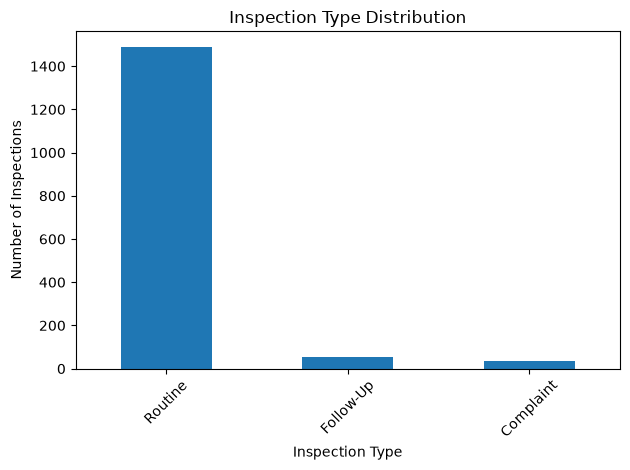

In [ ]:
# Insepction Type
df["Inspection_type"].value_counts().plot(
    kind="bar"
)

plt.title('Inspection Type Distribution')
plt.xlabel('Inspection Type')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

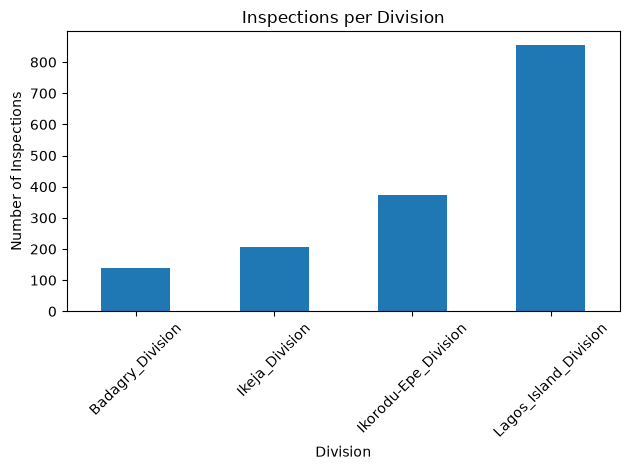

In [ ]:
# Create inspection counts by division
df_counts = (
	df.groupby("division")
	.size()
	.reset_index(name="inspection_count")
)

# Filter out the '1' division row
df_counts = df_counts[df_counts["division"] != "1"].copy()

# Clean up labels: remove the trailing "_1"
df_counts["division"] = df_counts["division"].str.replace(r"_1$", "", regex=True)

# Re-plot
df_counts.plot(kind="bar", x="division", y="inspection_count", legend=False)
plt.title("Inspections per Division")
plt.xlabel("Division")
plt.ylabel("Number of Inspections")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()